# Finding the Kevin Bacon of the Anime Industry

## Data Setup

In [3]:
import kagglehub
import pandas as pd
import networkx as nx
import itertools
import os
import numpy as np
import matplotlib.pyplot as plt

C:\Users\Christine\AppData\Local\Temp\ipykernel_20560\2031188509.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [4]:
path = kagglehub.dataset_download("furkanark/myanimelist-top-10000-anime-dataset")

anime_df = pd.read_csv(os.path.join(path, "anime.csv"))
entity_df = pd.read_csv(os.path.join(path, "entities.csv"))
va_df = pd.read_csv(os.path.join(path, "anime_voice_actors.csv"))
characters_df = pd.read_csv(os.path.join(path, "anime_characters.csv"))

print(f"Loaded {len(anime_df)} titles and {len(va_df)} voice acting credits.")

Loaded 10000 titles and 69846 voice acting credits.


## Preprocessing

In [39]:
# Filter for Japanese voice actors only
va_df = va_df[va_df['language'] == 'Japanese']

# Merge anime titles, characters and voice actors IDs
merged_df = pd.merge(characters_df[["anime_id", "character_id"]], va_df[["character_id", "person_id"]], left_on='character_id', right_on='character_id')

# Join to get anime titles
merged_df = pd.merge(merged_df, anime_df[["anime_id", "title"]], left_on='anime_id', right_on='anime_id')

# Join to get voice actor names
merged_df = pd.merge(merged_df, entity_df[["entity_id", "name"]], left_on='person_id', right_on='entity_id')

# Drop unnecessary columns and rename for clarity
merged_df = merged_df[["anime_id", "title", "name"]].rename(columns={"anime_id": "anime_id", "title": "anime_title", "name": "voice_actor"})

# Get only unique combinations of anime and voice actors
merged_df = merged_df.drop_duplicates()

print("Dataset shape: ", merged_df.shape)
merged_df.head()

Dataset shape:  (152952, 3)


,anime_id,anime_title,voice_actor
0,28977,Gintama°,"Sugita, Tomokazu"
28,28977,Gintama°,"Kugimiya, Rie"
45,28977,Gintama°,"Oogami, Izumi"
50,28977,Gintama°,"Kuwashima, Houko"
59,28977,Gintama°,"Saiga, Mitsuki"


## Network Modeling

In [ ]:
G = nx.Graph()

# Group by anime and create edges between all actors in the same production (Cartesian product)
for anime_title, group in merged_df.groupby('anime_title'):
    actors = group['voice_actor'].tolist()
    # Create connections between every pair of actors in this anime
    if len(actors) > 1:
        for pair in itertools.combinations(actors, 2):
            G.add_edge(pair[0], pair[1], label=anime_title)

print(f"Graph constructed with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph constructed with 4614 nodes and 470639 edges.


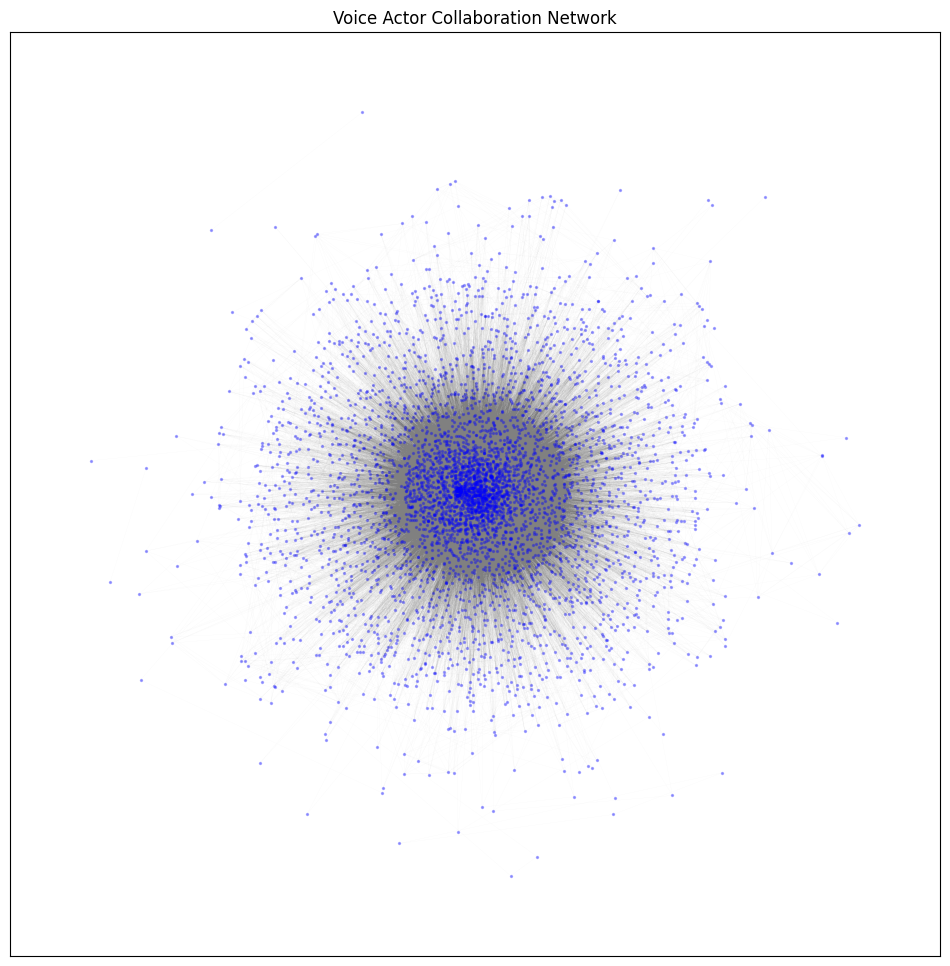

In [ ]:
# Draw graph using a layout that spreads nodes out

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.1, iterations=20)
nx.draw_networkx_nodes(G, pos, node_size=2, node_color='blue', alpha=0.3)
nx.draw_networkx_edges(G, pos, width=0.1, edge_color='gray', alpha=0.1)

plt.title("Voice Actor Collaboration Network")
plt.show()

## Centralities

In [ ]:
# Calculate Closeness Centrality to find the 'Kevin Bacon' of Anime
print("Calculating Closeness Centrality (this may take a few minutes)...")
closeness = nx.closeness_centrality(G)

# Sort and identify the top actor
kevin_bacon_anime = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[0]

print(f"The 'Kevin Bacon' of the Anime Industry is: {kevin_bacon_anime[0]}")
print(f"Closeness Score: {kevin_bacon_anime[1]:.4f}")

Calculating Closeness Centrality (this may take a few minutes)...
The 'Kevin Bacon' of the Anime Industry is: Sawashiro, Miyuki
Closeness Score: 0.6300


## Small World Validation

In [ ]:
# Find the Largest Connected Component (LCC)
components = sorted(nx.connected_components(G), key=len, reverse=True)
LCC = G.subgraph(components[0])

n_lcc = LCC.number_of_nodes()
m_lcc = LCC.number_of_edges()

print(f"Original Graph nodes: {G.number_of_nodes()}")
print(f"LCC nodes: {n_lcc} ({n_lcc/G.number_of_nodes():.1%} of the industry)")

# Random Graph (ER) for comparison 
random_G = nx.gnm_random_graph(n_lcc, m_lcc)
random_components = sorted(nx.connected_components(random_G), key=len, reverse=True)
random_LCC = random_G.subgraph(random_components[0])

# Empirical calculations on LCC and Random Graph
print("Empirical calculations (this may take a few minutes)...")

# Empirical Calculations on the LCC
avg_path = nx.average_shortest_path_length(LCC)
avg_cluster = nx.average_clustering(LCC)

random_cluster = nx.average_clustering(random_LCC)
random_path = nx.average_shortest_path_length(random_LCC)

print("\n--- Small World Validation (LCC) ---")
print(f"Empirical (Anime): Clustering coefficient = {avg_cluster:.4f}, Average shortest path length = {avg_path:.2f}")
print(f"Random (Control):  Clustering coefficient = {random_cluster:.4f}, Average shortest path length = {random_path:.2f}")

# Small World Check: C_empirical >> C_random AND L_empirical ≈ L_random
if avg_cluster > (random_cluster * 10) and abs(avg_path - random_path) < 3:
    print("\nResult: Small World Phenomenon Confirmed.")
else:
    print("\nResult: Small World Phenomenon NOT confirmed.")

Original Graph nodes: 4614
LCC nodes: 4604 (99.8% of the industry)
Empirical calculations (this may take a few minutes)...


## Shortest Path Length Distribution

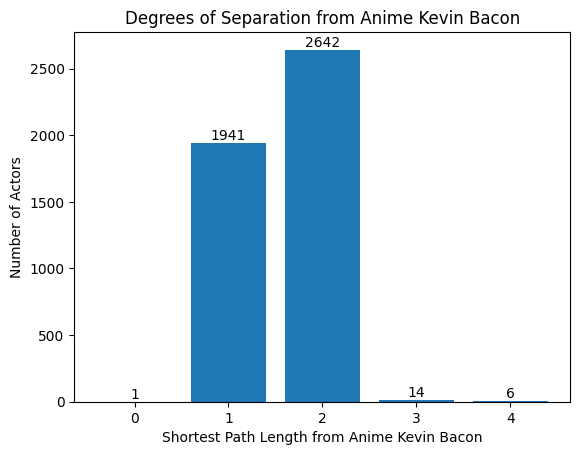

In [53]:
from collections import Counter

# Find lengths from the 'Kevin Bacon' actor to all others
bacon = "Sawashiro, Miyuki"  
lengths = nx.single_source_shortest_path_length(G, bacon)

# Plot frequency of path lengths
freq = Counter(lengths.values())

x = sorted(freq.keys())
y = [freq[i] for i in x]

bars = plt.bar(x, y)
plt.xlabel("Shortest Path Length from Anime Kevin Bacon")
plt.ylabel("Number of Actors")
plt.title("Degrees of Separation from Anime Kevin Bacon")

# Annotate bars with counts
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.show()